<a href="https://colab.research.google.com/github/SMN-SENAMHI/C3Smensual/blob/main/ECMWF_SUD_anomPrecTmaxTmin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Las siguientes gráficas se basan en la base de datos de **Copernicus Climate Data Store (C3S)** en su versión actualizada.  
Permiten visualizar el pronóstico mensual de los principales modelos climáticos globales para las **anomalías de temperatura máxima, temperatura mínima y precipitación**. Sitematizado en el SENAMHI PERÚ

**Consultas:** [smn@senamhi.gob.pe](mailto:smn@senamhi.gob.pe) | [jllamocca@senamhi.gob.pe](mailto:jllamocca@senamhi.gob.pe)





In [93]:
# Instalar librerías necesarias
!pip install xarray cartopy matplotlib pandas scipy geopandas > /dev/null 2>&1

In [110]:
#@title Selección de parámetros
Pais_seleccion = "Argentina" #@param ["Brasil", "Colombia", "Venezuela", "Argentina", "Bolivia", "Chile", "Costa Rica", "Ecuador", "French Guiana", "Guyana", "Océano Pacífico", "Panamá", "Paraguay", "Perú", "Suriname", "Uruguay"]
Modelo = "JMA"      #@param ["ECMWF", "UKMO", "METEO-FRANCE", "DWD", "CMCC", "NCEP", "JMA", "ECCC", "BOM"]
print(f"País seleccionado: {Pais_seleccion}")
print(f"Modelo seleccionado: {Modelo}")


País seleccionado: Argentina
Modelo seleccionado: JMA


Actualizado: SUDAMERICA.shp
Actualizado: SUDAMERICA.dbf
Actualizado: SUDAMERICA.shx
Actualizado: flx.anom.jma.nc

 País seleccionado: Argentina
Modelo seleccionado: JMA
Bounds: [-73.58537629 -55.05478161 -53.65138475 -21.78396425]
'forecast_reference_time' no encontrado → se usará la fecha actual como referencia.


Procesando tpara:   0%|          | 0/6 [00:00<?, ?it/s]

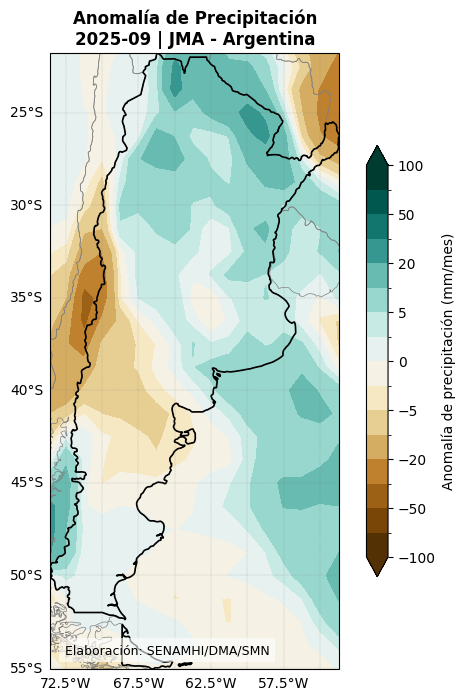

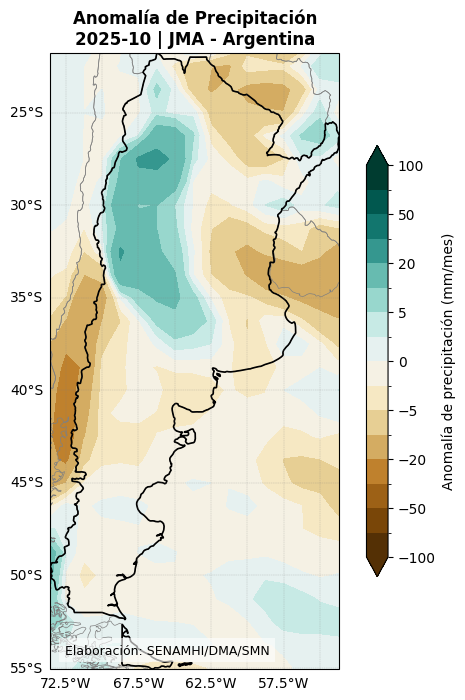

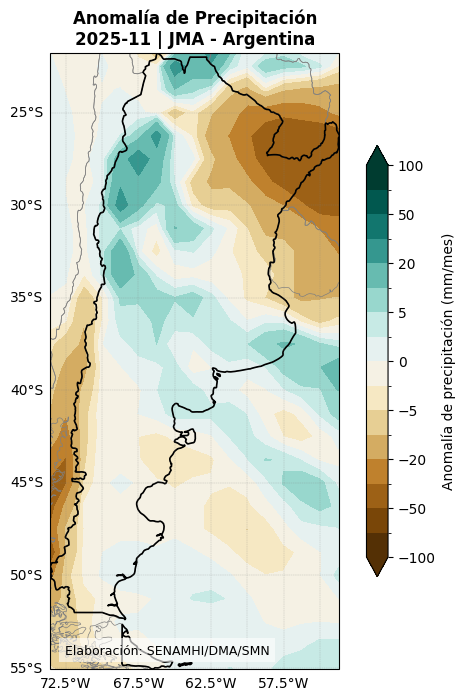

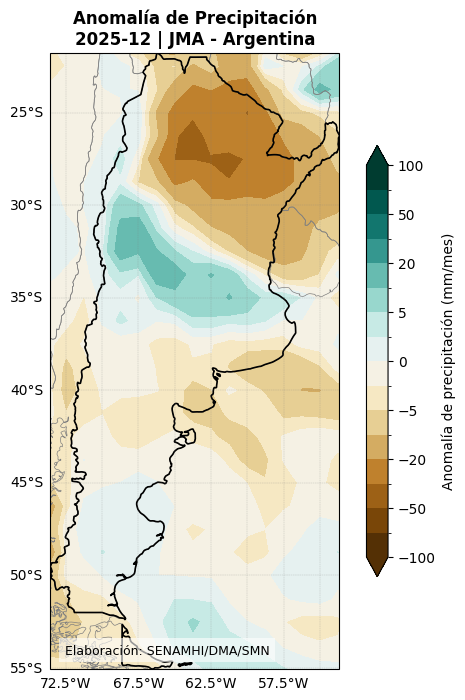

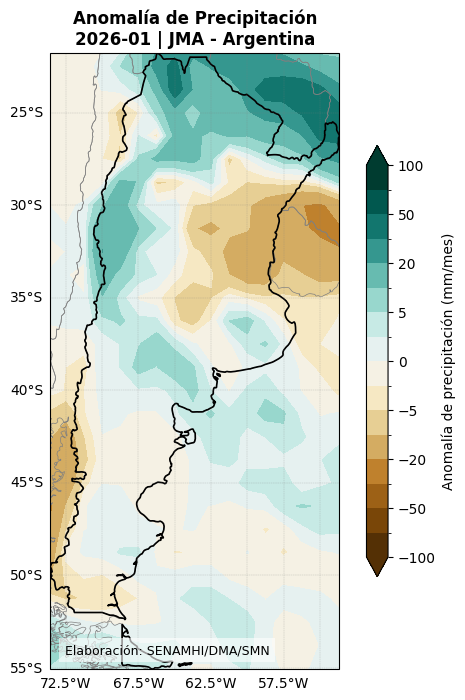

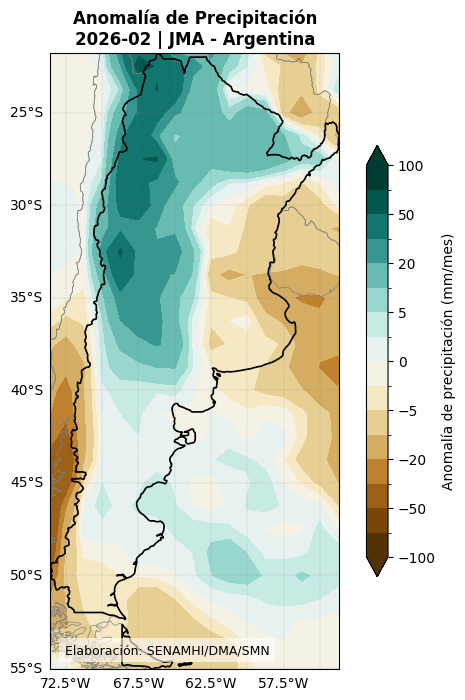

Procesando mx2t24a:   0%|          | 0/6 [00:00<?, ?it/s]

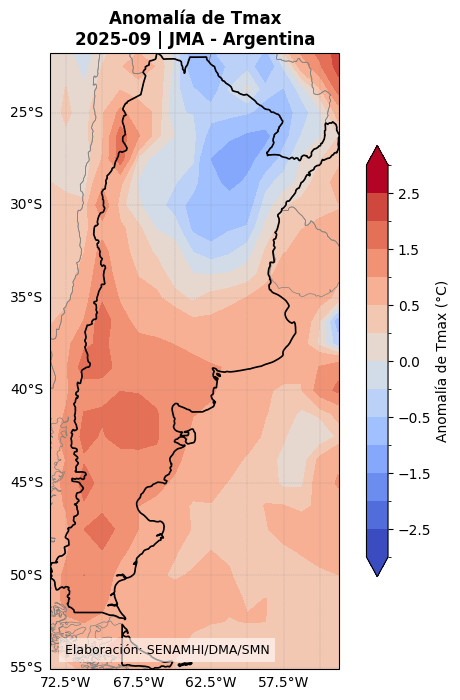

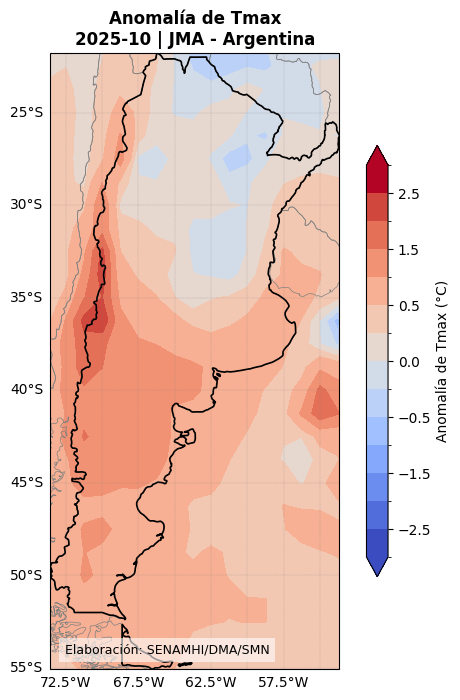

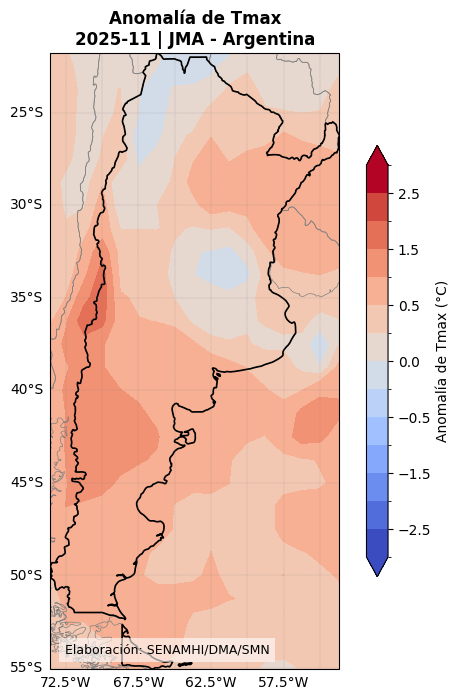

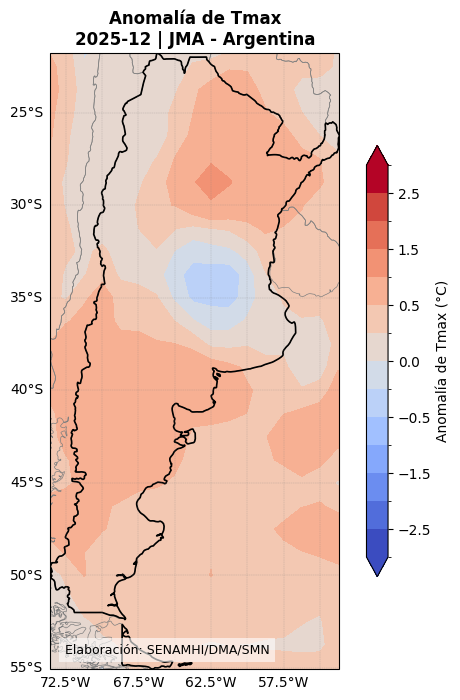

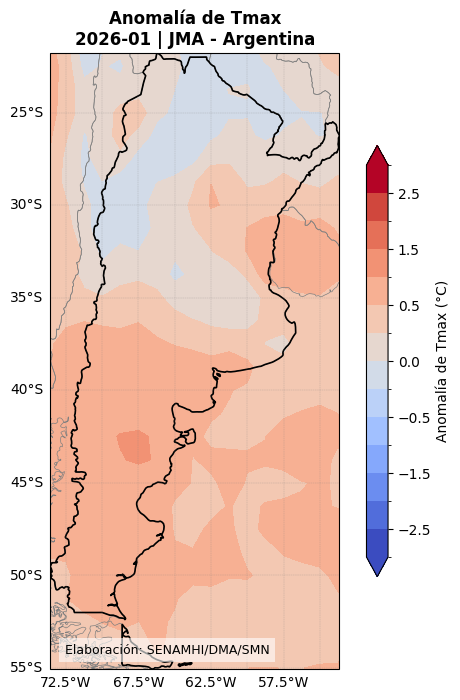

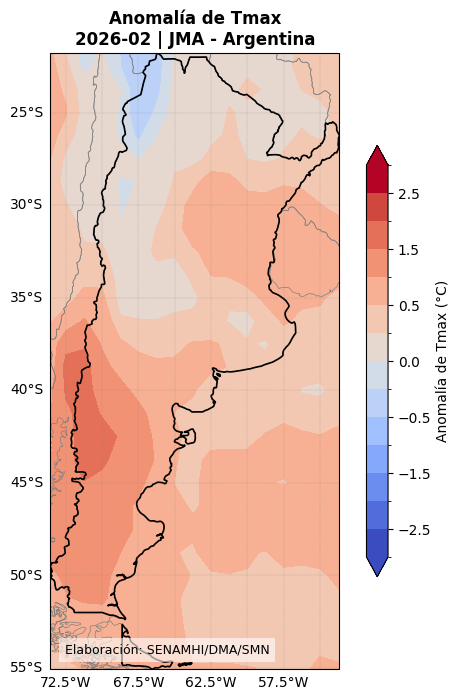

Procesando mn2t24a:   0%|          | 0/6 [00:00<?, ?it/s]

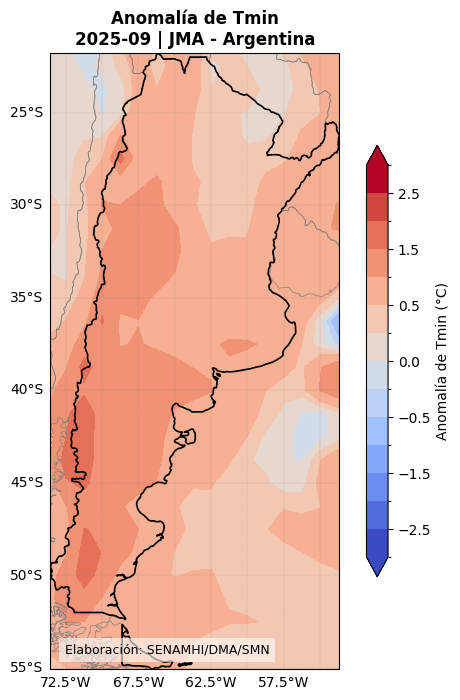

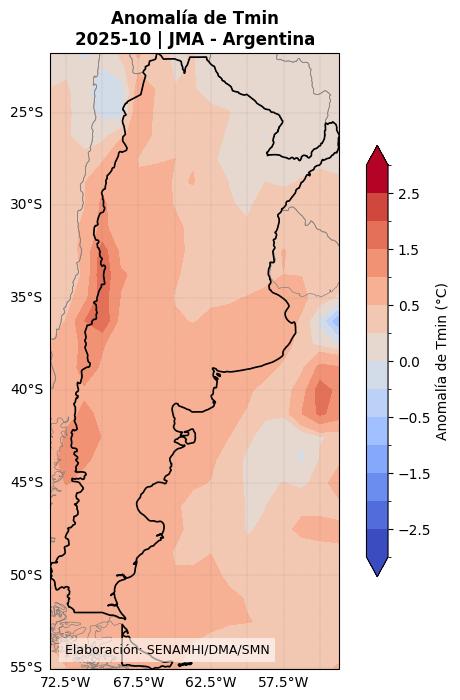

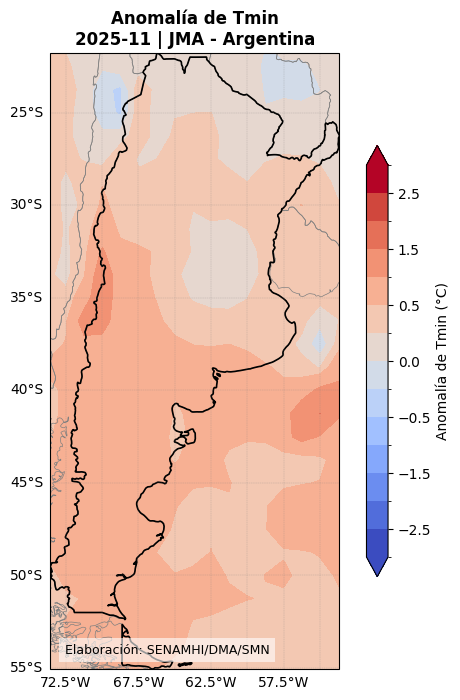

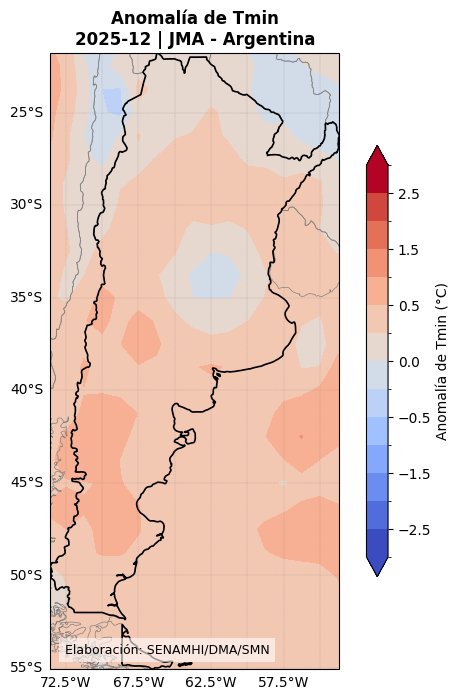

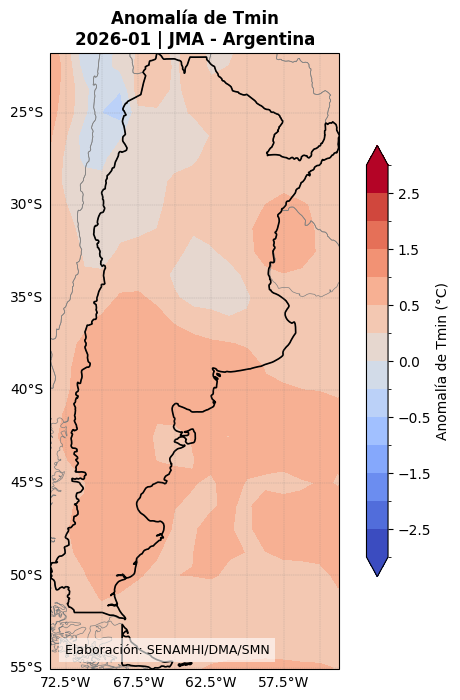

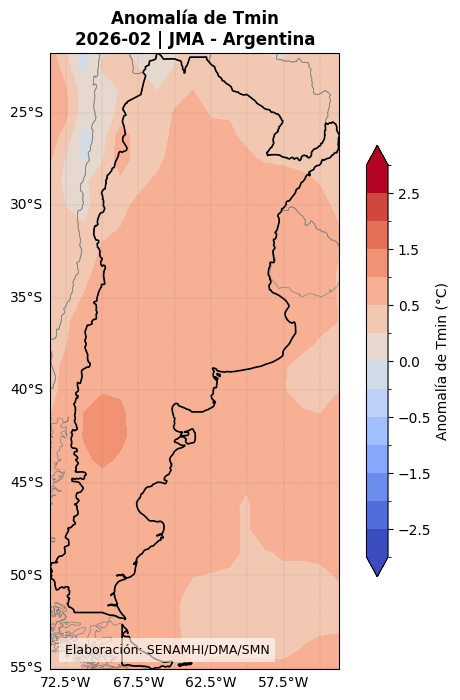

Proceso completado.


In [111]:
#@title Script principal (clic para mostrar/ocultar)
import os
import requests
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
from matplotlib.colors import BoundaryNorm
import pandas as pd
import geopandas as gpd
from tqdm.notebook import tqdm  # para barra de progreso

# ==========================
# FUNCIONES AUXILIARES
# ==========================
def download_file(url, local_path):
    r = requests.get(url, stream=True)
    if r.status_code == 200:
        with open(local_path, "wb") as f:
            f.write(r.content)
        print(f"Actualizado: {local_path}")
    else:
        print(f"Error {r.status_code} al descargar {url}")

# ==========================
# SHAPEFILE
# ==========================
shapefiles = {
    "SUDAMERICA.shp": "https://raw.githubusercontent.com/SMN-SENAMHI/Materiales/main/shape/SUDAMERICA.shp",
    "SUDAMERICA.dbf": "https://raw.githubusercontent.com/SMN-SENAMHI/Materiales/main/shape/SUDAMERICA.dbf",
    "SUDAMERICA.shx": "https://raw.githubusercontent.com/SMN-SENAMHI/Materiales/main/shape/SUDAMERICA.shx",
}
for name, url in shapefiles.items():
    download_file(url, name)

# ==========================
# ARCHIVO NETCDF SEGÚN MODELO
# ==========================
model_file = Modelo.lower()
data_url   = f"https://raw.githubusercontent.com/SMN-SENAMHI/C3Smensual/main/data/flx.anom.{model_file}.nc"
local_nc   = f"flx.anom.{model_file}.nc"
download_file(data_url, local_nc)

# ==========================
# CARGA SHAPEFILE Y PAÍS
# ==========================
gdf = gpd.read_file("SUDAMERICA.shp").set_crs("EPSG:32718").to_crs("EPSG:4326")
gdf["NOMBRE"] = gdf["NOMBRE"].replace({"PerÃº": "Perú", "Panama": "Panamá"})

gdf_pais = gdf[gdf["NOMBRE"].str.upper() == Pais_seleccion.upper()]
if gdf_pais.empty:
    raise ValueError(f"No se encontró el país '{Pais_seleccion}' en el shapefile.")

print(f"\n País seleccionado: {Pais_seleccion}")
print(f"Modelo seleccionado: {Modelo}")
print("Bounds:", gdf_pais.total_bounds)

# ==========================
# CARGAR MODELO
# ==========================
ds = xr.open_dataset(local_nc)

if "tpara" in ds:
    segundos_mes = 30 * 24 * 3600
    ds["tpara"] = ds["tpara"] * 1000 * segundos_mes

ds = ds.assign_coords(longitude=(((ds.longitude + 180) % 360) - 180)).sortby("longitude")

if "forecast_reference_time" in ds.coords:
    ref_time = pd.to_datetime(ds["forecast_reference_time"].values[0])
else:
    # fallback: usar fecha fija o la actual si no existe
    ref_time = pd.Timestamp.today().normalize()
    print("'forecast_reference_time' no encontrado → se usará la fecha actual como referencia.")

# ==========================
# VARIABLES
# ==========================
variables_info = {
   "tpara": {
        "cmap": "BrBG",
        "bounds": [-100, -80, -50, -30, -20, -10, -5, -2.5, 0, 2.5, 5, 10, 20, 30, 50, 80, 100],
        "title": "Anomalía de Precipitación",
        "label": "Anomalía de precipitación (mm/mes)"
    },
   "mx2t24a": {
        "cmap": "coolwarm",
        "bounds": np.array([-3,-2.5,-2,-1.5,-1,-0.5,-0.25,0,0.25,0.5,1,1.5,2,2.5,3]),
        "title": "Anomalía de Tmax",
        "label": "Anomalía de Tmax (°C)"
    },
   "mn2t24a": {
        "cmap": "coolwarm",
        "bounds": np.array([-3,-2.5,-2,-1.5,-1,-0.5,-0.25,0,0.25,0.5,1,1.5,2,2.5,3]),
        "title": "Anomalía de Tmin",
        "label": "Anomalía de Tmin (°C)"
    }
}

# ==========================
# FUNCIÓN DE PLOT
# ==========================
def plot_variable(var, info, fm, ref_time, gdf, gdf_pais, pais_nombre):
    variable_fm = ds[var].sel(forecastMonth=fm)
    lon, lat, values = ds["longitude"].values, ds["latitude"].values, variable_fm.values.squeeze()
    minx, miny, maxx, maxy = gdf_pais.total_bounds

    fig, ax = plt.subplots(figsize=(7, 8), subplot_kw={"projection": ccrs.PlateCarree()})
    norm = BoundaryNorm(info["bounds"], ncolors=256)
    cs = ax.contourf(lon, lat, values, levels=info["bounds"], cmap=info["cmap"], norm=norm, extend="both")

    gdf.boundary.plot(ax=ax, color="gray", linewidth=0.5)
    gdf_pais.boundary.plot(ax=ax, color="black", linewidth=1.2)
    ax.set_extent([minx, maxx, miny, maxy], crs=ccrs.PlateCarree())

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False

    fecha = ref_time + pd.DateOffset(months=fm-1)
    ax.set_title(f"{info['title']}\n{fecha.strftime('%Y-%m')} | {Modelo} - {pais_nombre}",
                 fontsize=12, fontweight="bold")

    cbar = fig.colorbar(cs, ax=ax, orientation="vertical", shrink=0.7)
    cbar.set_label(info["label"])

    ax.text(0.05, 0.02, 'Elaboración: SENAMHI/DMA/SMN',
            horizontalalignment='left', verticalalignment='bottom',
            transform=ax.transAxes, fontsize=9, color='black',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
    plt.show()

# ==========================
# LOOP DE PLOTS con barra de progreso
# ==========================
for var, info in variables_info.items():
    for fm in tqdm(ds["forecastMonth"].values, desc=f"Procesando {var}"):
        plot_variable(var, info, fm, ref_time, gdf, gdf_pais, Pais_seleccion)

print("Proceso completado.")


In [112]:
#@title Selección de parámetros
Region = "Sudamérica"  #@param ["Sudamérica"]
Modelo = "JMA"       #@param ["ECMWF", "UKMO", "METEO-FRANCE", "DWD", "CMCC", "NCEP", "JMA", "ECCC", "BOM"]

print(f"Región seleccionada: {Region}")
print(f"Modelo seleccionado: {Modelo}")


Región seleccionada: Sudamérica
Modelo seleccionado: JMA


Archivo descargado exitosamente: flx.anom.jma.nc
 'forecast_reference_time' no encontrado → usando fecha actual como referencia.


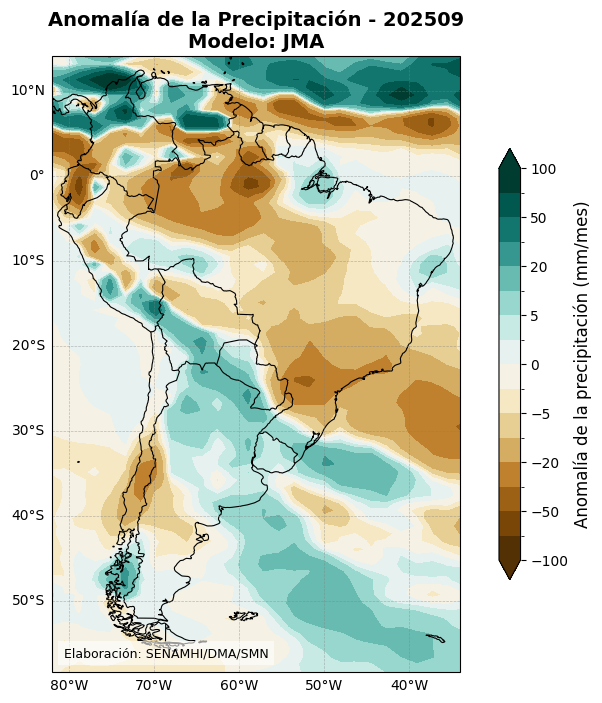

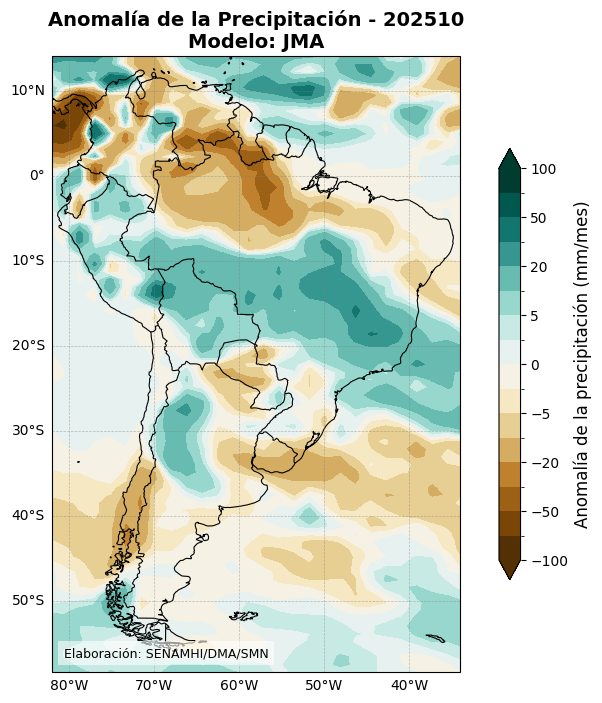

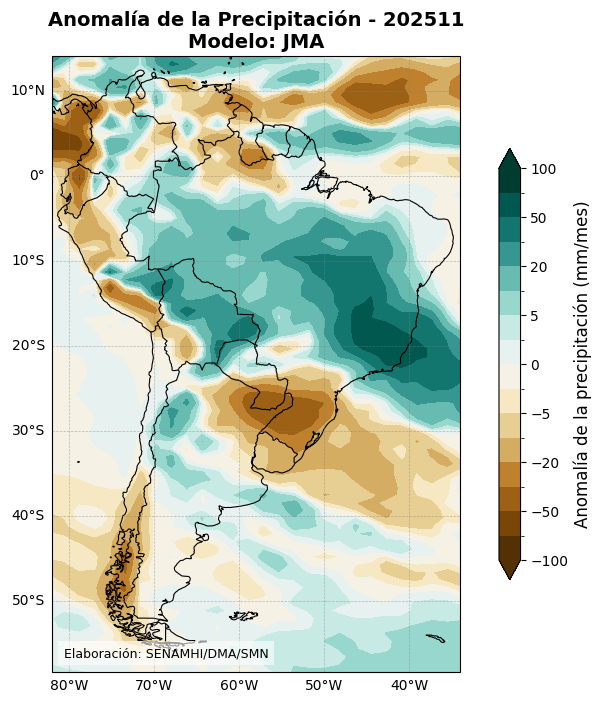

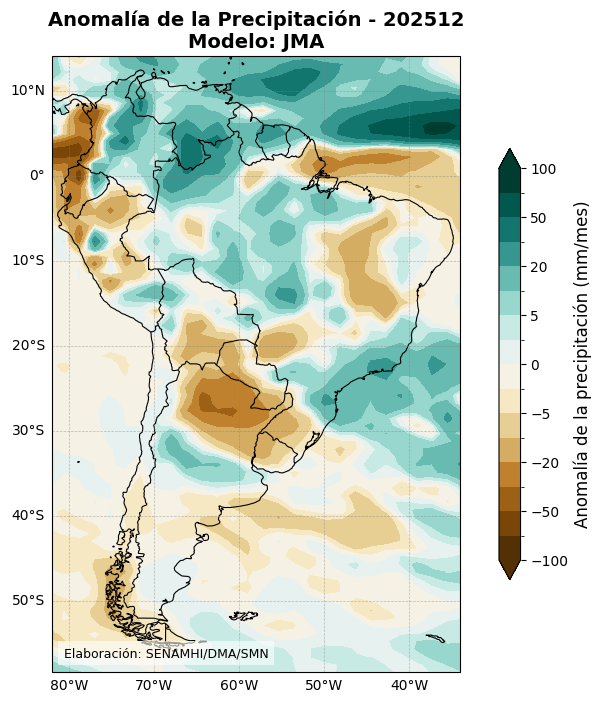

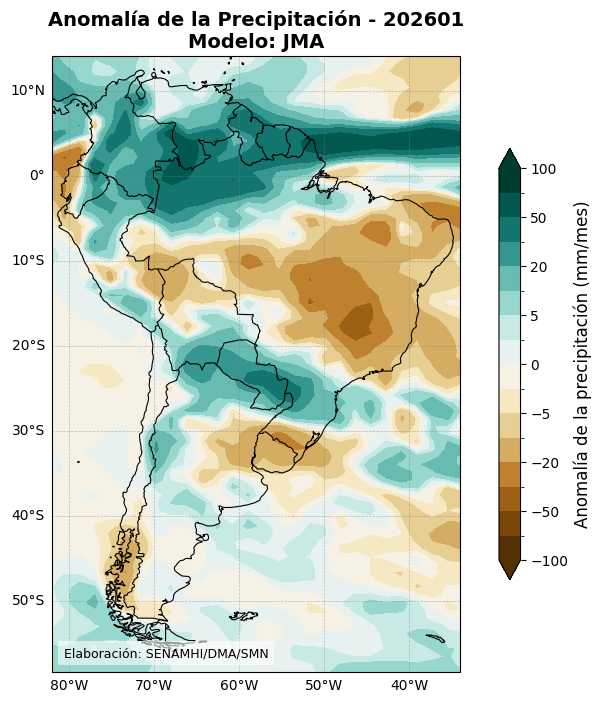

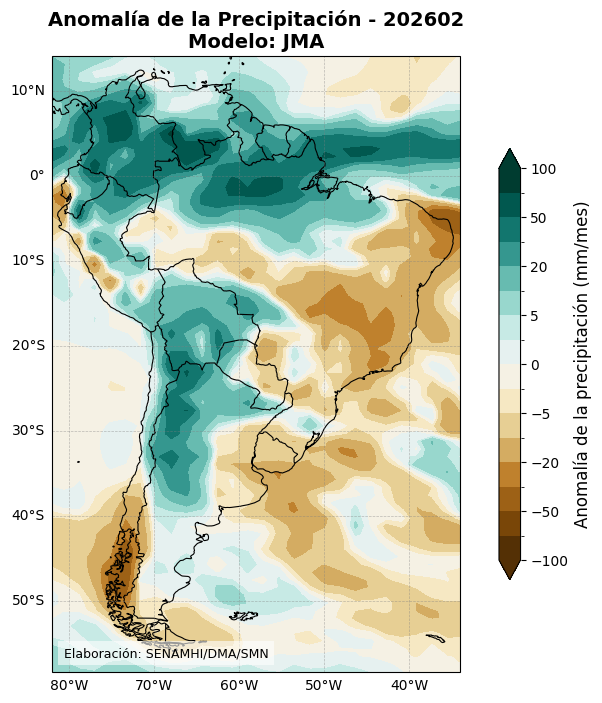

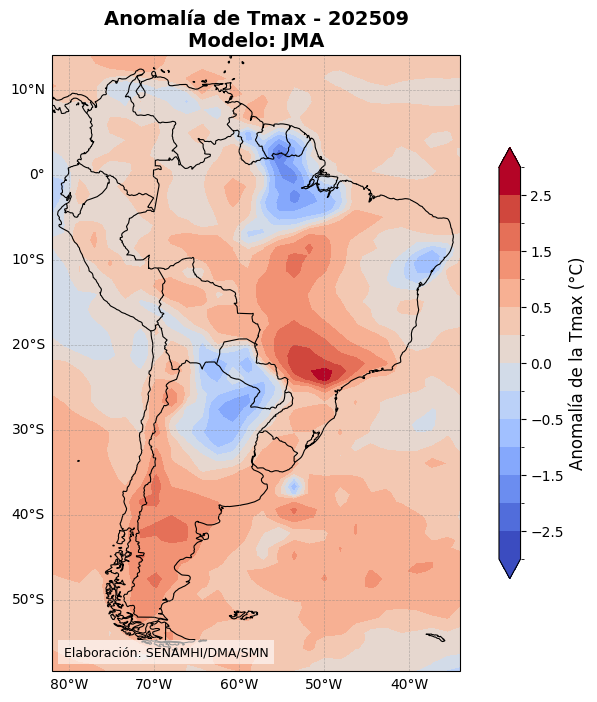

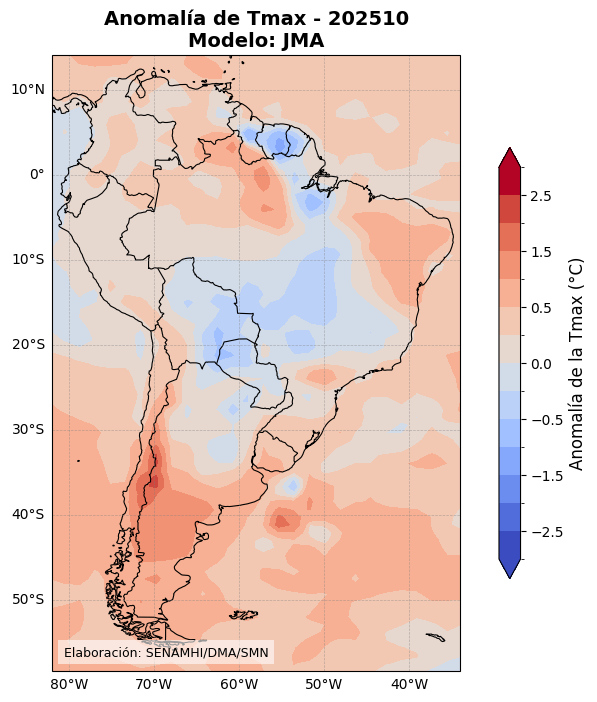

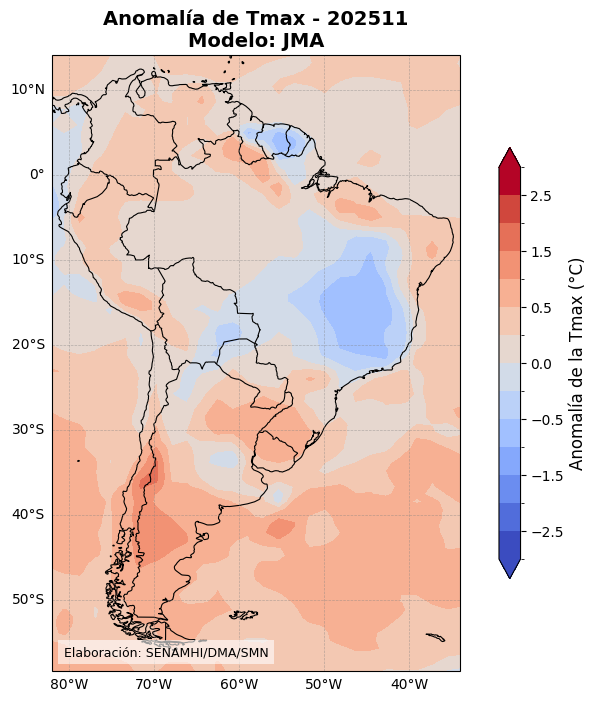

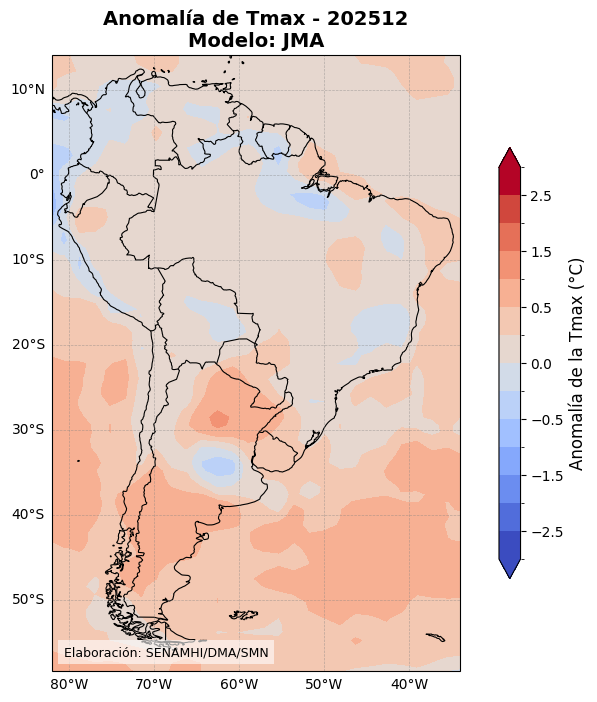

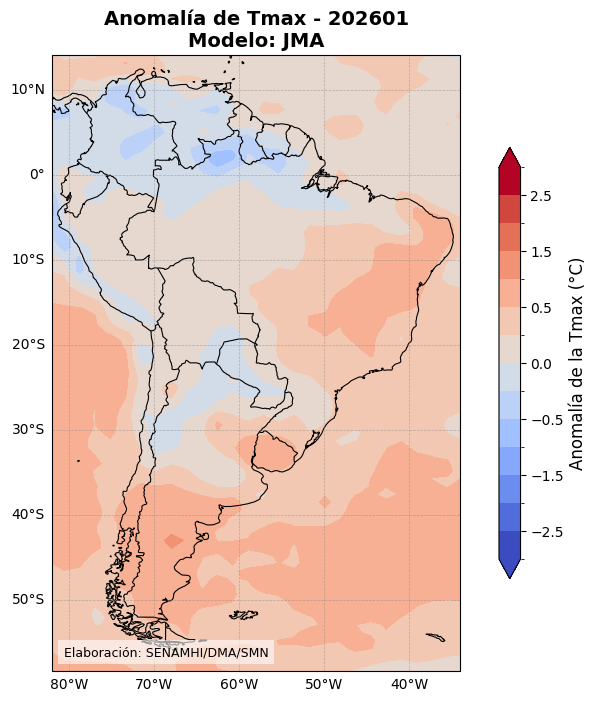

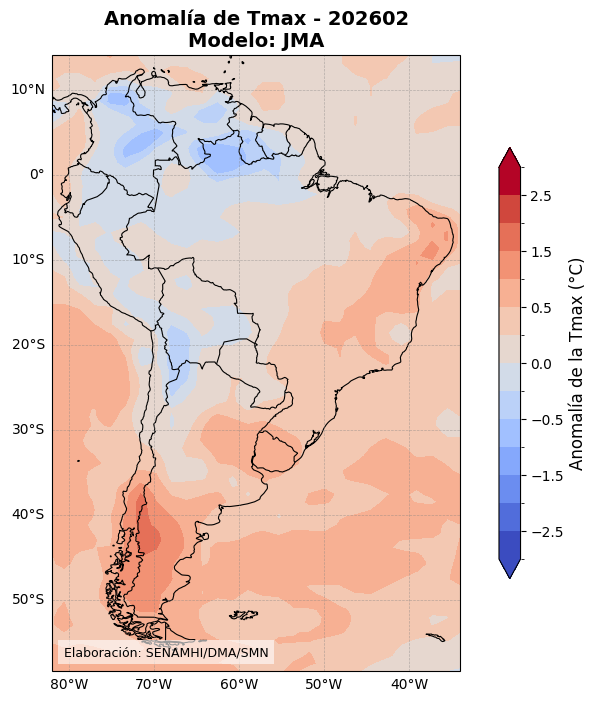

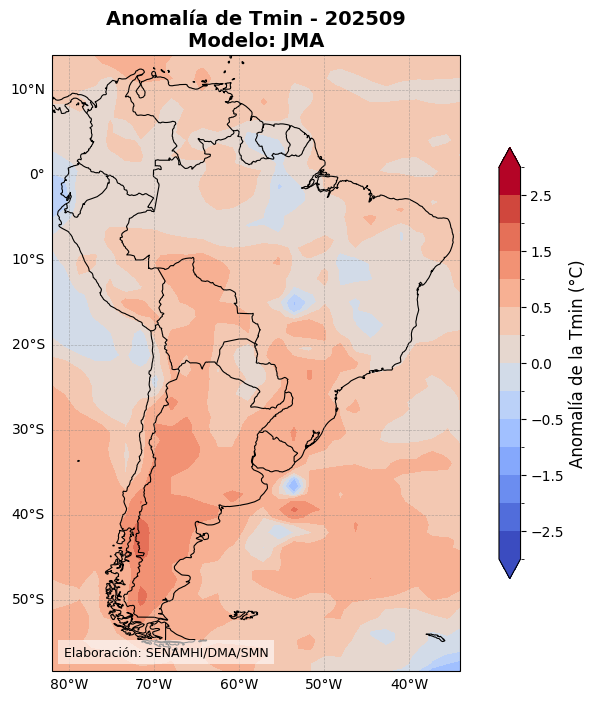

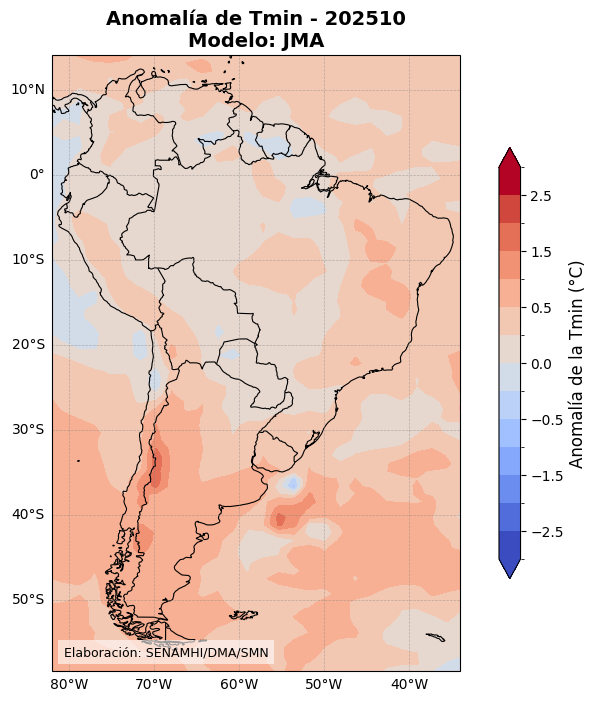

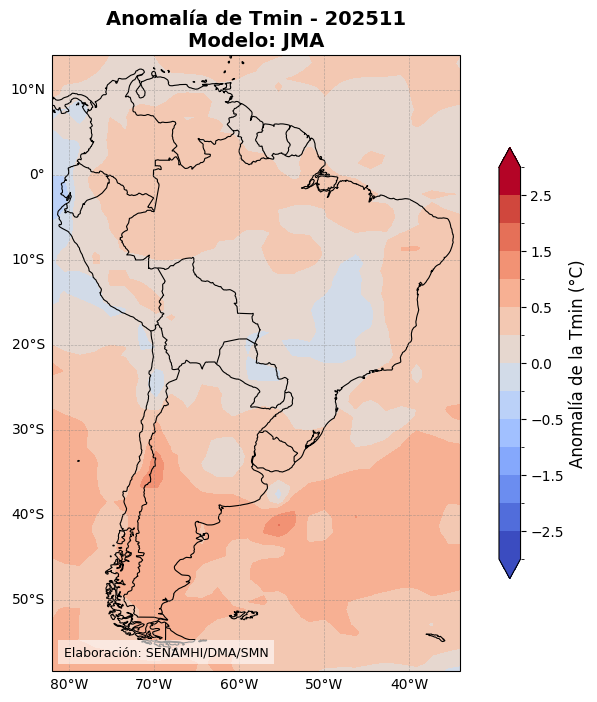

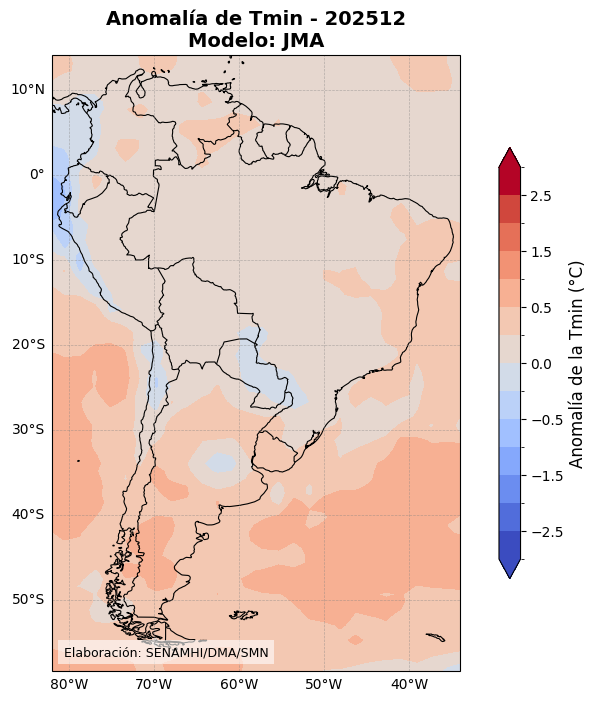

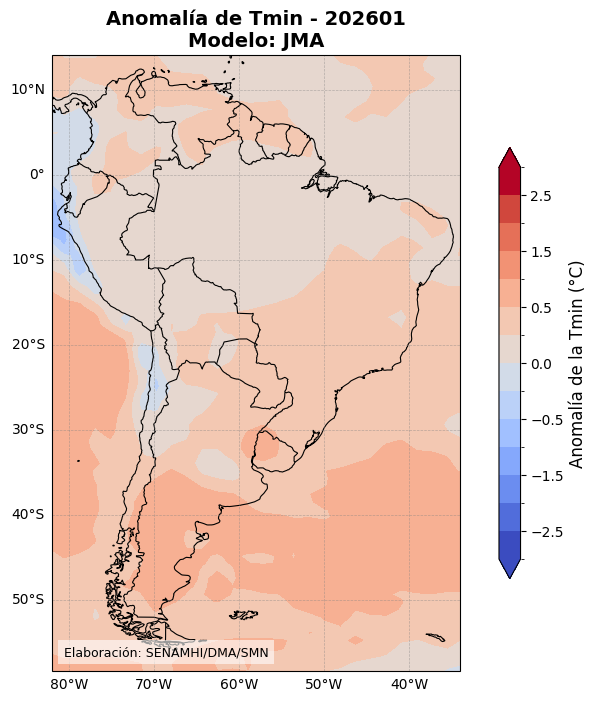

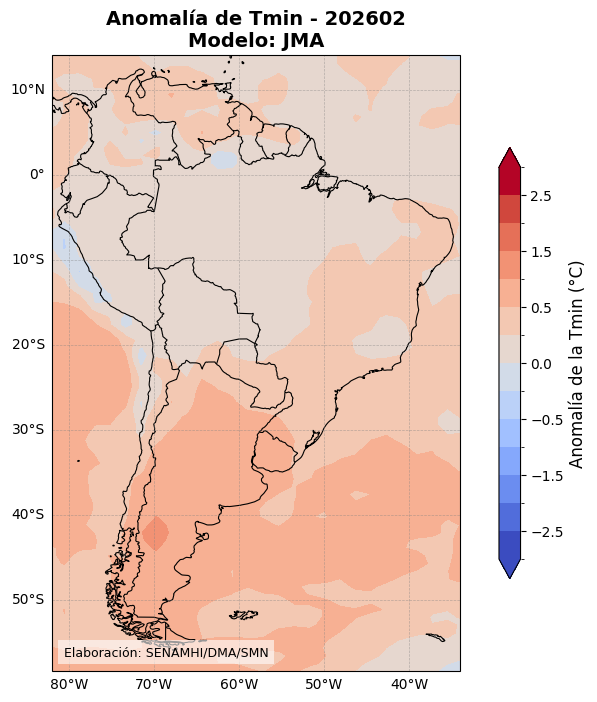

In [105]:
#@title Script principal (clic para mostrar/ocultar)
import os
import requests
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
from matplotlib.colors import BoundaryNorm
import pandas as pd
from scipy.interpolate import griddata
import matplotlib.ticker as mticker
import cartopy.feature as cfeature
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="cartopy")


# --------------------------
# Función para descargar archivos desde una URL
# --------------------------
def download_file(url, local_path):
    try:
        response = requests.get(url, stream=True)
        if response.status_code == 200:
            with open(local_path, "wb") as f:
                f.write(response.content)
            print(f"Archivo descargado exitosamente: {local_path}")
        else:
            print(f"Error al descargar el archivo: {response.status_code}")
    except Exception as e:
        print(f"Error durante la descarga: {e}")

# --------------------------
# Descarga dinámica del modelo elegido en Celda 1
# --------------------------
model_file = Modelo.lower()
data_url = f"https://raw.githubusercontent.com/SMN-SENAMHI/C3Smensual/main/data/flx.anom.{model_file}.nc"
local_data_file = f"flx.anom.{model_file}.nc"
download_file(data_url, local_data_file)

# Extensión fija para Sudamérica
extent = [-82.0, -34.0, -56.0, 13.0]

# Cargar dataset
ds = xr.open_dataset(local_data_file)

# Manejo de forecast_reference_time
if "forecast_reference_time" in ds.coords:
    ref_time = pd.to_datetime(ds["forecast_reference_time"].values[0])
else:
    ref_time = pd.Timestamp.today().normalize()
    print(" 'forecast_reference_time' no encontrado → usando fecha actual como referencia.")


def cubic_interpolation(variable, lon, lat, new_lon, new_lat):
    lon2d, lat2d = np.meshgrid(lon, lat)
    points = np.array([lon2d.flatten(), lat2d.flatten()]).T
    values = variable.values.flatten()

    new_lon2d, new_lat2d = np.meshgrid(new_lon, new_lat)
    new_points = np.array([new_lon2d.flatten(), new_lat2d.flatten()]).T

    interpolated_values = griddata(points, values, new_points, method='cubic')
    return interpolated_values.reshape(new_lon2d.shape)

# --------------------------
# Función de plot
# --------------------------
def plot_variable(variable, variable_name, cmap, bounds, norm, title_prefix,
                  output_dir, filename_suffix, colorbar_label, modelo, ref_time):

    for fm in range(1, 7):
        if "forecastMonth" in variable.coords:
            variable_fm = variable.sel(forecastMonth=fm)
        else:
            continue

        forecast_date = pd.to_datetime(ref_time) + pd.DateOffset(months=fm - 1)
        date_str = forecast_date.strftime("%Y%m")

        lon = variable_fm["longitude"].values
        lat = variable_fm["latitude"].values

        new_lon = np.linspace(lon.min(), lon.max(), 200)
        new_lat = np.linspace(lat.min(), lat.max(), 200)

        interpolated_values = cubic_interpolation(variable_fm, lon, lat, new_lon, new_lat)

        fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": ccrs.PlateCarree()})

        if not np.isnan(interpolated_values).all():
            plot = ax.contourf(new_lon, new_lat, interpolated_values, levels=bounds,
                               cmap=cmap, norm=norm, extend="both")

            ax.add_feature(cfeature.BORDERS, edgecolor="black", linewidth=0.8)
            ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
            ax.add_feature(cfeature.LAND, edgecolor="black", facecolor="none", linewidth=0.6)

            ax.set_title(f"{title_prefix} - {date_str}\nModelo: {modelo.upper()}",
                         fontsize=14, fontweight="bold")

            ax.set_extent(extent)

            gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
            gl.xlocator = mticker.MultipleLocator(10)
            gl.ylocator = mticker.MultipleLocator(10)
            gl.top_labels = False
            gl.right_labels = False

            cbar = fig.colorbar(plot, ax=ax, orientation="vertical", shrink=0.7)
            cbar.set_label(colorbar_label, fontsize=12)

            ax.text(0.53, 0.02, "Elaboración: SENAMHI/DMA/SMN",
                    horizontalalignment="right", verticalalignment="bottom",
                    transform=ax.transAxes, fontsize=9, color="black",
                    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"))

            filename = f"pre_{modelo}_{date_str}_{filename_suffix}_sudamerica.png"
            plt.savefig(os.path.join(output_dir, filename), dpi=300, bbox_inches="tight")
            plt.show()

        else:
            ax.set_title(f"Datos no disponibles - {date_str}")
            ax.set_extent(extent)
            plt.show()

        plt.close()

# --------------------------
# Directorio de salida
# --------------------------
output_dir = "graphics"
os.makedirs(output_dir, exist_ok=True)

# --------------------------
# Variables a procesar
# --------------------------
variables_info = {
    "tpara": {
        "cmap": "BrBG",
        "bounds": np.array([-100, -80, -50, -30, -20, -10, -5, -2.5, 0, 2.5, 5, 10, 20, 30, 50, 80, 100]),
        "title_prefix": "Anomalía de la Precipitación",
        "filename_suffix": "anomPrec",
        "colorbar_label": "Anomalía de la precipitación (mm/mes)"
    },
    "mx2t24a": {
        "cmap": "coolwarm",
        "bounds": np.array([-3, -2.5, -2, -1.5, -1, -0.5, -0.25, 0, 0.25, 0.5, 1, 1.5, 2, 2.5, 3]),
        "title_prefix": "Anomalía de Tmax",
        "filename_suffix": "anomTempMax",
        "colorbar_label": "Anomalía de la Tmax (°C)"
    },
    "mn2t24a": {
        "cmap": "coolwarm",
        "bounds": np.array([-3, -2.5, -2, -1.5, -1, -0.5, -0.25, 0, 0.25, 0.5, 1, 1.5, 2, 2.5, 3]),
        "title_prefix": "Anomalía de Tmin",
        "filename_suffix": "anomTempMin",
        "colorbar_label": "Anomalía de la Tmin (°C)"
    }

}

# --------------------------
# Procesamiento
# --------------------------
if "tpara" in ds:
    segundos_por_mes = 30 * 24 * 3600
    ds["tpara"] = ds["tpara"] * 1000 * segundos_por_mes

for var, info in variables_info.items():
    if var in ds:
        variable = ds[var]
        norm = BoundaryNorm(boundaries=info["bounds"], ncolors=256)
        plot_variable(variable, var, info["cmap"], info["bounds"], norm,
                      info["title_prefix"], output_dir,
                      info["filename_suffix"], info["colorbar_label"], Modelo, ref_time)
